In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 

In [2]:
data = '../data/raw/train_transaction.csv'

In [3]:
df = pd.read_csv(data)

In [4]:
df.shape

(590540, 394)

In [5]:
# the features denoted by V seem to be highly collerated with groups of matching numbers of missing data.
#table them for now to zoom in on the features I can engineer something from and understand with clarity.

In [6]:

v_columns = df.filter(regex=r'^V\d+').columns
df_lean = df.drop(columns=v_columns)

In [7]:
pd.set_option('display.max_columns', None )

In [8]:
df_lean.head(50)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,0,86400,68.500,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN
1,2987001,0,86401,29.000,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,2987002,0,86469,59.000,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F
3,2987003,0,86499,50.000,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,2987004,0,86506,50.000,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2987005,0,86510,49.000,W,5937,555.0,150.0,visa,226.0,debit,272.0,87.0,36.0,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,M1,F,T,NaN,NaN,NaN
6,2987006,0,86522,159.000,W,12308,360.0,150.0,visa,166.0,debit,126.0,87.0,0.0,NaN,yahoo.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,M0,F,F,T,T,T
7,2987007,0,86529,422.500,W,12695,490.0,150.0,visa,226.0,debit,325.0,87.0,NaN,NaN,mail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,F,F,NaN,NaN,NaN
8,2987008,0,86535,15.000,H,2803,100.0,150.0,visa,226.0,debit,337.0,87.0,NaN,NaN,anonymous.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2987009,0,86536,117.000,W,17399,111.0,150.0,mastercard,224.0,debit,204.0,87.0,19.0,NaN,yahoo.com,NaN,2.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,1.0,0.0,12.0,2.0,61.0,61.0,30.0,318.0,30.0,NaN,NaN,NaN,NaN,40.0,302.0,NaN,NaN,NaN,318.0,T,T,T,M0,T,T,NaN,NaN,NaN


In [9]:
#create a userId for feature engineering 
#TransactionID: high cardinality will be dropped from training feature set 
#isFraud: Target
#TransactionDT: a time delta from a given date to protect user info the signal remains the same 
#TransactionAmt: how much was spent during the transaction
#1.transform : log transform the amount
#2.engineer: deviation from a user's Id's mean, new_user x high_value interaction, floating point extraction(speculative),transaction_count per user,deviations from product cd median and addr1.
# ProductCD: categorical product type 
# card_features: card 1 = card number cardinal useful for identifying user, card 2 ?,card 3 is country of bank cross check against addr 2, card 4 is card type categorical, card 6 is debit or credit, card 5 ?
#addr1: a zip code fill nan with -1
#addr2: a country , engineer a feature that flags a discrepency between the billing country(card 3) and country(addr 2) if card 3= 150 addr2 = 87 fill nan with -1
#dist 1 : distance from physical store
#dist 2 : distance of ip address from billing address missing 94% may have to drop but it could encode useful data.
#R_emaildomain: recipient email (where to depo the purchase), frauds may lean towards choosing an encrypted email like anonymous.com ,categorise them into trusted and less know 
#P_emaildomain: purchasers email domain same treatment as the R_email.
#normalize all D features by subtracting them from the TransactionDT data from them after converting TransactionDT to days 
#C and M will have the Nan imputed with a -1 and thats it M is categorical and must be handled as such so fill mising with 'missing'(looks for matches between info A and info B) C are counts 
#V is to be handled by sectioning them each into groups collapsing down each group by correlation to get most signal with least amount of noise, adn releasing each feature from the group in until rocauc stops increasing .



In [10]:
df.addr1.value_counts().head(20)

addr1
299.0    46335
325.0    42751
204.0    42020
264.0    39870
330.0    26287
315.0    23078
441.0    20827
272.0    20141
123.0    16105
126.0    15243
184.0    15160
337.0    15149
191.0    14979
181.0    13856
143.0     9806
476.0     9478
310.0     8486
472.0     8478
327.0     8425
512.0     8268
Name: count, dtype: int64

In [11]:
df_lean.R_emaildomain.isna().sum()

np.int64(453249)

In [12]:
# category= [ProductCD(native),card3(change for xgboost) , card2(change for xgboost), card1(unique identifier averaging 40 transactions per one may drop), card 4(native handling),
#card5(native lgbm change for xgboost),card6(native), addr2(may drop or make binary america or not america flag, P_email_domain and R_email_domain(native) impute missing with a 'missing' flag, 
#M features are categorical impute with 'missing' flag, group for forward selection.]

In [13]:
#continuous = [TransactionAmt,TransactionDT(normalize), dist1 and dist2 impute missing with a -1 flag test removal they are highly sparse dist2 95% and dist 1 60%,
#the counts have no missing values just zeros but i will group them for forward selection those that have high correlation, 
#impute Deltas/D with missing -1 flag some are highly sparse 85% percent and above normalize d1 against the transactionDT, again group for forward selection ]

In [14]:
#build user_id's  aggregate over the user id's 
# feed the user_id's directly into a catboost model to test if not easily can drop?
# V columns PCA 90%  per subgroup grouped by no.of missing values 
# C columns PCA 95%
#user_id has to be strict 
#transaction velocities
# deviations in device type or operating system from usual card 
#


In [15]:
# 1. Create the normalized D columns first
for i in range(1, 16):
    # Some D columns might have missing values; handling NaNs is important
    df_lean[f'D{i}_N'] = (df_lean['TransactionDT'] / 86400) - df_lean[f'D{i}']

# 2. Construct the user_id using the newly created D1_N
# Note: rounding D1_N to an integer or 1 decimal place helps group matches 
# that have minor floating-point differences.
# Use fillna('') on columns that might contain missing values before joining them
df_lean['D1_N_floored'] = np.floor(df_lean['D1_N']).fillna(-999).astype('int32')
df_lean['user_id'] = (
    df_lean['card1'].fillna('').astype(str) + '_' + 
    df_lean['card2'].fillna('').astype(str) + '_' + 
    df_lean['card3'].fillna('').astype(str) + '_' + 
    df_lean['addr1'].fillna('').astype(str) + '_' + 
    df_lean['addr2'].fillna('').astype(str) + '_' + 
    df_lean['D1_N_floored'].astype(str)
)

# Now check again, it will output 0 nulls!
print(df_lean['user_id'].isna().sum())
# 3. Drop the old D columns AFTER you are completely done using them
cols_to_drop = [f'D{i}' for i in range(1, 15)]
df_lean.drop(columns=cols_to_drop, inplace=True)

0


In [16]:
df_lean.head(50)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,D1_N,D2_N,D3_N,D4_N,D5_N,D6_N,D7_N,D8_N,D9_N,D10_N,D11_N,D12_N,D13_N,D14_N,D15_N,D1_N_floored,user_id
0,2987000,0,86400,68.500,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,-13.000000,NaN,-12.000000,NaN,NaN,NaN,NaN,NaN,NaN,-12.000000,-12.000000,NaN,NaN,NaN,1.000000,-13,13926__150.0_315.0_87.0_-13
1,2987001,0,86401,29.000,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,1.000012,NaN,NaN,1.000012,NaN,NaN,NaN,NaN,NaN,1.000012,NaN,NaN,NaN,NaN,1.000012,1,2755_404.0_150.0_325.0_87.0_1
2,2987002,0,86469,59.000,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,315.0,T,T,T,M0,F,F,F,F,F,1.000799,NaN,NaN,1.000799,NaN,NaN,NaN,NaN,NaN,1.000799,-313.999201,NaN,NaN,NaN,-313.999201,1,4663_490.0_150.0_330.0_87.0_1
3,2987003,0,86499,50.000,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN,-110.998854,-110.998854,1.001146,-92.998854,1.001146,NaN,NaN,NaN,NaN,-82.998854,NaN,NaN,NaN,NaN,-109.998854,-111,18132_567.0_150.0_476.0_87.0_-111
4,2987004,0,86506,50.000,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.001227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4497_514.0_150.0_420.0_87.0_1
5,2987005,0,86510,49.000,W,5937,555.0,150.0,visa,226.0,debit,272.0,87.0,36.0,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,T,T,T,M1,F,T,NaN,NaN,NaN,1.001273,NaN,NaN,1.001273,NaN,NaN,NaN,NaN,NaN,1.001273,1.001273,NaN,NaN,NaN,1.001273,1,5937_555.0_150.0_272.0_87.0_1
6,2987006,0,86522,159.000,W,12308,360.0,150.0,visa,166.0,debit,126.0,87.0,0.0,NaN,yahoo.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,T,T,T,M0,F,F,T,T,T,1.001412,NaN,NaN,1.001412,NaN,NaN,NaN,NaN,NaN,1.001412,1.001412,NaN,NaN,NaN,1.001412,1,12308_360.0_150.0_126.0_87.0_1
7,2987007,0,86529,422.500,W,12695,490.0,150.0,visa,226.0,debit,325.0,87.0,NaN,NaN,mail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,M0,F,F,NaN,NaN,NaN,1.001493,NaN,NaN,1.001493,NaN,NaN,NaN,NaN,NaN,1.001493,NaN,NaN,NaN,NaN,1.001493,1,12695_490.0_150.0_325.0_87.0_1
8,2987008,0,86535,15.000,H,2803,100.0,150.0,visa,226.0,debit,337.0,87.0,NaN,NaN,anonymous.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.001562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2803_100.0_150.0_337.0_87.0_1
9,2987009,0,86536,117.000,W,17399,111.0,150.0,mastercard,224.0,debit,204.0,87.0,19.0,NaN,yahoo.com,NaN,2.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,1.0,0.0,12.0,2.0,318.0,T,T,T,M0,T,T,NaN,NaN,NaN,-59.998426,-59.998426,-28.998426,-316.998426,-28.998426,NaN,NaN,NaN,NaN,-38.998426,-300.998426,NaN,NaN,NaN,-316.998426,-60,17399_111.0_150.0_204.0_87.0_-60


In [17]:
df_lean.user_id.isna().sum()

np.int64(0)

In [18]:
check_user = df_lean.loc[df_lean['user_id'] == '9917_142.0_185.0___117']

In [19]:
pd.set_option('display.max_rows',None)

In [20]:
check_user.head(129)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,D1_N,D2_N,D3_N,D4_N,D5_N,D6_N,D7_N,D8_N,D9_N,D10_N,D11_N,D12_N,D13_N,D14_N,D15_N,D1_N_floored,user_id
401144,3388144,1,10109872,81.446,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.012407,NaN,NaN,117.012407,NaN,117.012407,NaN,NaN,NaN,117.012407,NaN,117.012407,117.012407,117.012407,117.012407,117,9917_142.0_185.0___117
401152,3388152,1,10109982,81.446,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0,1.0,0.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.013681,NaN,117.013681,117.013681,117.013681,117.013681,117.013681,NaN,NaN,117.013681,NaN,117.013681,117.013681,117.013681,117.013681,117,9917_142.0_185.0___117
401164,3388164,1,10110148,40.723,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.015602,NaN,NaN,117.015602,NaN,117.015602,NaN,NaN,NaN,117.015602,NaN,117.015602,117.015602,117.015602,117.015602,117,9917_142.0_185.0___117
401166,3388166,1,10110185,40.723,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,2.0,2.0,0.0,2.0,0.0,2.0,2.0,4.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.016030,NaN,117.016030,117.016030,117.016030,117.016030,117.016030,NaN,NaN,117.016030,NaN,117.016030,117.016030,117.016030,117.016030,117,9917_142.0_185.0___117
401204,3388204,1,10110631,40.723,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.021192,NaN,NaN,117.021192,NaN,117.021192,NaN,NaN,NaN,117.021192,NaN,117.021192,117.021192,117.021192,117.021192,117,9917_142.0_185.0___117
401206,3388206,1,10110664,78.667,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0,2.0,0.0,1.0,0.0,1.0,1.0,2.0,0.0,2.0,2.0,2.0,1.0,1.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.021574,NaN,NaN,117.021574,117.021574,117.021574,117.021574,NaN,NaN,117.021574,NaN,117.021574,117.021574,117.021574,117.021574,117,9917_142.0_185.0___117
401251,3388251,1,10111633,40.723,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.032789,NaN,NaN,117.032789,NaN,117.032789,NaN,NaN,NaN,117.032789,NaN,117.032789,117.032789,117.032789,117.032789,117,9917_142.0_185.0___117
401258,3388258,1,10111686,40.723,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,2.0,1.0,0.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.033403,NaN,NaN,117.033403,117.033403,117.033403,117.033403,NaN,NaN,117.033403,NaN,117.033403,117.033403,117.033403,117.033403,117,9917_142.0_185.0___117
401290,3388290,1,10112139,40.723,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,3.0,1.0,0.0,1.0,0.0,1.0,1.0,3.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.038646,NaN,NaN,117.038646,117.038646,117.038646,117.038646,NaN,NaN,117.038646,NaN,117.038646,117.038646,117.038646,117.038646,117,9917_142.0_185.0___117
401303,3388303,1,10112419,32.264,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,1.0,gmail.com,gmail.com,8.0,13.0,0.0,2.0,0.0,2.0,2.0,7.0,0.0,3.0,4.0,4.0,1.0,1.0,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,117.041887,NaN,NaN,-108.958113,117.041887,-108.958113,117.041887,NaN,NaN,117.041887,NaN,-108.958113,117.041887,116.041887,117.041887,117,9917_142.0_185.0___117


In [21]:
#d15N and d10N,d4n good indicators of differences;find a way to relate some of these user id's they seem a tad bit too specific some are being split based on rounding errors when they are clearly the same profile
#loosen the userid by flooring instead of rounding the d1n or flooring the transaction date after conversion(better)

In [22]:
#velocity spamming same purchase
#look for sudden devaition in velocity of purchases 
#same purchase counter 
#transaction hour
#deviation from the median transactionamt of the uid
#does email change from the first transaction of the card 
#does c1 stagnate for block of purchases
#does dist2 change
#how many emails linked to the card 
#deviation from addr1 median 
#loosen the userid by flooring instead of rounding the d1n or flooring the transaction date after conversion(better)
#feed the d15n,d10n,d4n std's from uid
# feed c13 nunique values 
# deviation from the global median of that product cd 
#c2 is a unique purchase counter linked to email and time i believe it does not go up if the same purchase was made within maybe 200 seconds before the last 
# does c2 change by 2 or more from last purchase linked to the uid if so then different cards or accounts model will know to split 
#strict user_id velocity tracker

In [23]:
#may need to group features 

In [24]:
#adversarial_validation:
#c12, c13,c14,c5 have high importance in the adversarial validation but it is to be expected counts go up naaturally as time passes
# we can get rid of c14 due to high correlation with c1, we can remove c5 and 12 as well but c13 serves as a unique identifier
# M2,M7,M4 are also high in the adversarial validation importance list 
# M2 and M7 can be removed due to redundancy, replaced by M1 and M8
# dist 1 and dist 2 they are subject to time drift dist 2 has 95% missing values experiment with removing both 
# product cd the type of product bought changes over time but i would think the most common fraud prodcut cd type remains C 
#addr1 less or more purchases from particular zipcode over time might remove addr1 is pretty specific and we can capture data using deviations from global mean
# alot of the time deltas have shifts over time but it is expected as new cards get made the distribution of the deltas skew
# 
 




In [31]:
df_fraud = df_lean.loc[df_lean['isFraud'] == 1]

In [32]:
df_fraud.shape

(20663, 58)

In [33]:
df_fraud.user_id.value_counts().head(27)

user_id
12695_490.0_150.0_325.0_87.0_-342    90
17188_321.0_150.0_122.0_87.0_-139    84
13623_585.0_150.0_498.0_87.0_117     80
9002_453.0_150.0_272.0_87.0_-92      78
2939_111.0_150.0_204.0_87.0_-137     76
9500_321.0_150.0_330.0_87.0_17       75
9917_142.0_185.0___117               64
9500_321.0_150.0_231.0_87.0_12       58
16927_310.0_150.0_203.0_87.0_-477    55
9917_142.0_185.0___116               54
14649_548.0_150.0_476.0_87.0_47      53
12473_555.0_150.0_299.0_87.0_81      46
5287_553.0_150.0_512.0_87.0_39       44
15885_545.0_185.0___163              42
9917_142.0_185.0___115               40
10057_225.0_150.0_204.0_87.0_28      39
10011_319.0_150.0_476.0_87.0_50      39
17480_528.0_150.0_191.0_87.0_55      38
5033_269.0_150.0_264.0_87.0_111      38
12616_490.0_150.0___-491             37
12544_321.0_150.0_337.0_87.0_-119    35
6457_321.0_150.0_325.0_87.0_-6       33
9633_130.0_185.0___15                33
9749_181.0_150.0_226.0_87.0_-5       33
11233_321.0_150.0_325.0_87.0_-37

In [28]:
df_fraud.head(50)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,D1_N,D2_N,D3_N,D4_N,D5_N,D6_N,D7_N,D8_N,D9_N,D10_N,D11_N,D12_N,D13_N,D14_N,D15_N,D1_N_floored,user_id
779,2987779,1,102154,10.0,S,7481,364.0,146.0,mastercard,166.0,debit,441.0,87.0,NaN,NaN,NaN,gmail.com,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.182338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,7481_364.0_146.0_441.0_87.0_1
780,2987780,1,102188,10.0,S,8732,360.0,150.0,mastercard,229.0,debit,441.0,87.0,NaN,NaN,NaN,gmail.com,35.0,29.0,0.0,21.0,0.0,5.0,0.0,38.0,0.0,58.0,24.0,0.0,54.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.817269,NaN,NaN,NaN,NaN,NaN,NaN,1.016065,1.016065,NaN,NaN,NaN,NaN,NaN,NaN,-18,8732_360.0_150.0_441.0_87.0_-18
781,2987781,1,102193,10.0,S,8732,360.0,150.0,mastercard,229.0,debit,441.0,87.0,NaN,NaN,NaN,gmail.com,35.0,29.0,0.0,21.0,0.0,5.0,0.0,38.0,0.0,58.0,24.0,0.0,54.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.817211,NaN,NaN,NaN,NaN,NaN,NaN,1.016123,1.016123,NaN,NaN,NaN,NaN,NaN,NaN,-18,8732_360.0_150.0_441.0_87.0_-18
2598,2989598,1,147621,100.0,S,2616,327.0,150.0,discover,223.0,credit,123.0,87.0,NaN,NaN,NaN,gmail.com,4.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.291424,-0.291424,NaN,NaN,NaN,NaN,NaN,-21.999756,1.000243,NaN,NaN,NaN,NaN,NaN,NaN,-1,2616_327.0_150.0_123.0_87.0_-1
3698,2990698,1,157997,10.0,S,8732,360.0,150.0,mastercard,229.0,debit,441.0,87.0,NaN,NaN,NaN,gmail.com,35.0,29.0,0.0,21.0,0.0,5.0,0.0,38.0,0.0,58.0,24.0,0.0,54.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.171331,NaN,NaN,NaN,NaN,NaN,NaN,1.037003,1.037003,NaN,NaN,NaN,NaN,NaN,NaN,-18,8732_360.0_150.0_441.0_87.0_-18
3704,2990704,1,158071,10.0,S,8732,360.0,150.0,mastercard,229.0,debit,441.0,87.0,NaN,NaN,NaN,gmail.com,35.0,29.0,0.0,21.0,0.0,5.0,0.0,38.0,0.0,58.0,24.0,0.0,54.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.170475,NaN,NaN,NaN,NaN,NaN,NaN,1.037859,1.037859,NaN,NaN,NaN,NaN,NaN,NaN,-18,8732_360.0_150.0_441.0_87.0_-18
3706,2990706,1,158108,10.0,S,8732,360.0,150.0,mastercard,229.0,debit,337.0,87.0,NaN,NaN,NaN,gmail.com,35.0,30.0,0.0,21.0,0.0,5.0,0.0,38.0,0.0,58.0,24.0,0.0,54.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.170046,NaN,NaN,NaN,NaN,NaN,NaN,1.038288,1.038288,NaN,NaN,NaN,NaN,NaN,NaN,-18,8732_360.0_150.0_337.0_87.0_-18
4763,2991763,1,169185,5.0,S,3821,111.0,150.0,mastercard,219.0,credit,272.0,87.0,NaN,NaN,NaN,yahoo.com,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.958160,NaN,NaN,NaN,NaN,1.958160,NaN,NaN,NaN,1.958160,NaN,NaN,NaN,NaN,NaN,1,3821_111.0_150.0_272.0_87.0_1
4797,2991797,1,169535,10.0,S,3821,111.0,150.0,mastercard,219.0,credit,272.0,87.0,NaN,NaN,NaN,yahoo.com,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.962211,1.962211,NaN,NaN,NaN,1.962211,1.962211,1.003878,1.003878,1.962211,NaN,NaN,NaN,NaN,NaN,1,3821_111.0_150.0_272.0_87.0_1
8629,2995629,1,255754,100.0,S,2616,327.0,150.0,discover,223.0,credit,123.0,87.0,NaN,NaN,NaN,gmail.com,4.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,7.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.039884,-0.039884,NaN,NaN,NaN,NaN,NaN,-21.998216,2.001783,NaN,NaN,NaN,NaN,NaN,NaN,-1,2616_327.0_150.0_123.0_87.0_-1


In [53]:
# 1. Group by 'uid' on the labeled dataset (where isFraud is present)
uid_stats = df_lean[df_lean['isFraud'].notna()].groupby('user_id').agg(
    total_tx=('TransactionID', 'count'),  # Total transactions for this UID
    has_fraud=('isFraud', 'max')           # 1 if UID has at least 1 fraud transaction
)

# 2. Filter for UIDs with > 5 transactions AND at least 1 fraud
fraud_uids_gt5 = uid_stats[(uid_stats['total_tx'] >) & (uid_stats['has_fraud'] == 1)]

# 3. Get the count of distinct UIDs
print(f"Number of fraudulent UIDs with > 5 transactions: {len(fraud_uids_gt5)}")

# Inspect the top UIDs matching the criteria
fraud_uids_gt5.sort_values(by='total_tx', ascending=False).head()

Number of fraudulent UIDs with > 5 transactions: 3769


,total_tx,has_fraud
user_id,,
12616_490.0_150.0___-491,211,1
15885_545.0_185.0___22,174,1
15885_545.0_185.0___27,137,1
15885_545.0_185.0___20,134,1
15885_545.0_185.0___29,132,1


--- Computing C-Columns Correlation Matrix ---

Highly Correlated C-Pairs (|r| >= 0.85): 4
  C1 <---> C14: 0.873
  C4 <---> C8: 0.9154
  C4 <---> C10: 0.8904
  C8 <---> C10: 0.9705

--- Computing M-Columns Correlation Matrix ---

Highly Correlated M-Pairs (|r| >= 0.80): 6
  M1 <---> M2: 0.9723
  M1 <---> M3: 0.9475
  M2 <---> M3: 0.971
  M7 <---> M8: 0.9208
  M7 <---> M9: 0.9166
  M8 <---> M9: 0.9132


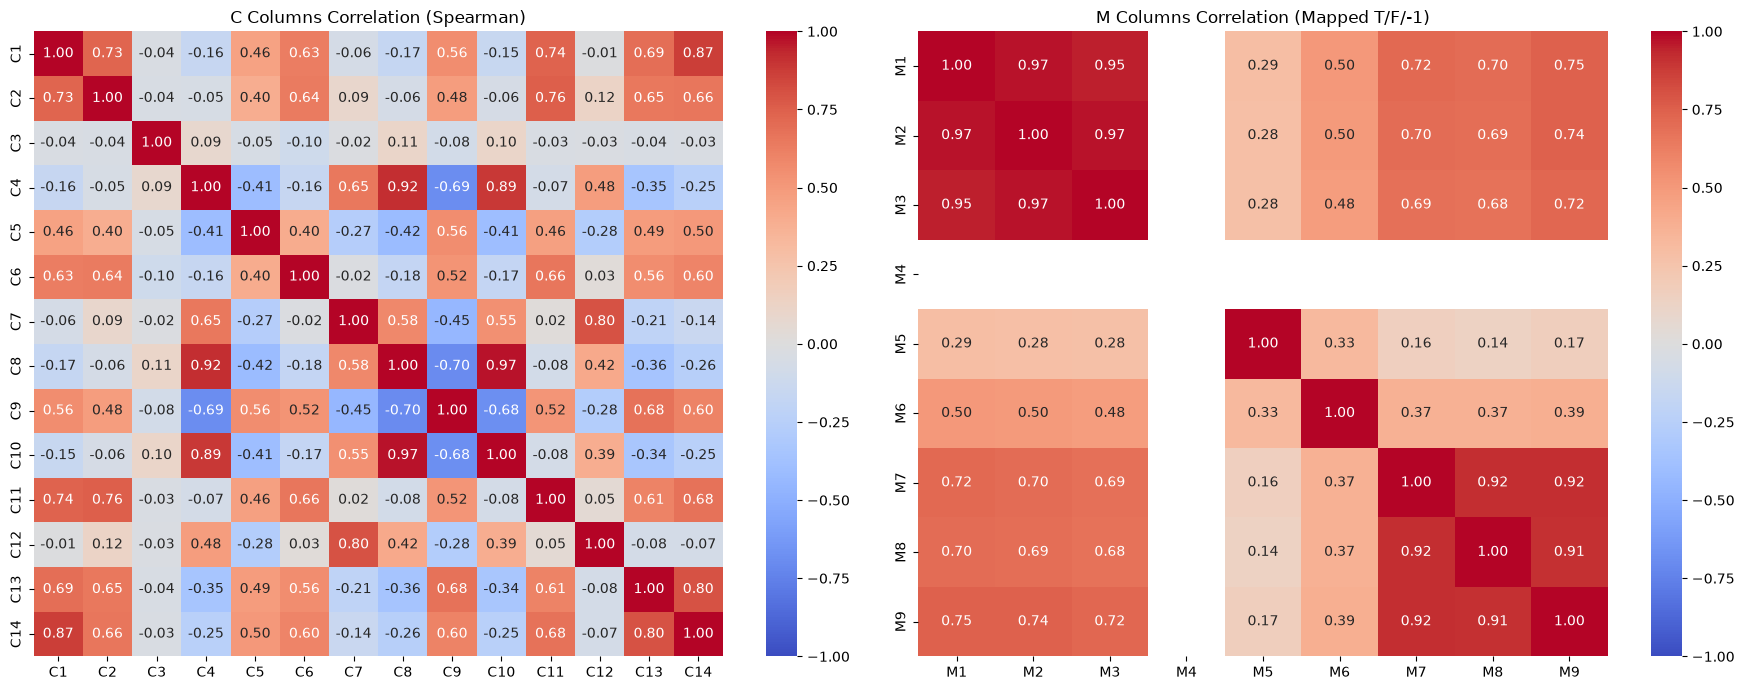

In [29]:
import matplotlib.pyplot as plt

# Define column groups
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in df.columns]
m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in df.columns]

# ==========================================
# 1. CONTINUOUS C-COLUMN CORRELATIONS
# ==========================================
print("--- Computing C-Columns Correlation Matrix ---")
c_corr = df[c_cols].corr(method='spearman') # Spearman is robust to heavy skew/outliers

# Find highly correlated pairs (|r| >= 0.85) to spot redundancy
high_c_pairs = []
for i in range(len(c_cols)):
    for j in range(i + 1, len(c_cols)):
        col1, col2 = c_cols[i], c_cols[j]
        val = c_corr.loc[col1, col2]
        if abs(val) >= 0.85:
            high_c_pairs.append((col1, col2, round(val, 4)))

print(f"\nHighly Correlated C-Pairs (|r| >= 0.85): {len(high_c_pairs)}")
for p in high_c_pairs:
    print(f"  {p[0]} <---> {p[1]}: {p[2]}")


# ==========================================
# 2. CATEGORICAL M-COLUMN CORRELATIONS
# ==========================================
print("\n--- Computing M-Columns Correlation Matrix ---")

# Map M boolean/string flags to numerical values for correlation testing
# 'T' -> 1, 'F' -> 0, 'missing' / NaN -> -1
m_mapped = df[m_cols].copy()
for col in m_cols:
    m_mapped[col] = m_mapped[col].map({'T': 1, 'F': 0}).fillna(-1).astype(int)

m_corr = m_mapped.corr(method='pearson')

high_m_pairs = []
for i in range(len(m_cols)):
    for j in range(i + 1, len(m_cols)):
        col1, col2 = m_cols[i], m_cols[j]
        val = m_corr.loc[col1, col2]
        if abs(val) >= 0.80:
            high_m_pairs.append((col1, col2, round(val, 4)))

print(f"\nHighly Correlated M-Pairs (|r| >= 0.80): {len(high_m_pairs)}")
for p in high_m_pairs:
    print(f"  {p[0]} <---> {p[1]}: {p[2]}")


# ==========================================
# 3. VISUALIZE HEATMAPS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(c_corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('C Columns Correlation (Spearman)')

sns.heatmap(m_corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('M Columns Correlation (Mapped T/F/-1)')

plt.tight_layout()
plt.show()